In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# === 1. Load data ===
df = pd.read_csv("Dataset/B90_102_exp30m_202104.csv")

# === 2. Convert time to datetime and sort ===
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")

# === 3. Keep required columns (including time) ===
cols = [
    "time",
    "room_temp",
    "thermostat_outside_temp",
    "damper_position",
    "airflow_current",
    "supply_discharge_temp",
    "clg_signal",
    "htg_signal",
    "htg_valve_position",
    "clg_sp_current",
    "htg_sp_current",
    "htg_clg_mode"
]

df = df[cols].copy()

# === 4. Create active setpoint ===
df["setpoint"] = (
    df["htg_clg_mode"] * df["htg_sp_current"] +
    (1 - df["htg_clg_mode"]) * df["clg_sp_current"]
)

# === 5. Create thermal signal ===
df["thermal_signal"] = (
    df["htg_clg_mode"] * df["htg_signal"] +
    (1 - df["htg_clg_mode"]) * df["clg_signal"]
)

# === 6. Drop separate setpoints ===
df = df.drop(columns=["clg_sp_current", "htg_sp_current"])

# === 7. Normalize numeric columns ===
num_cols = [
    "room_temp",
    "thermostat_outside_temp",
    "damper_position",
    "airflow_current",
    "supply_discharge_temp",
    "clg_signal",
    "htg_signal",
    "htg_valve_position",
    "setpoint",
    "thermal_signal"
]

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# === 8. Set time as index ===
df = df.set_index("time")

# === 9. Drop NA and ensure ascending ===
df = df.dropna().sort_index()
print(df.head())

                     room_temp  thermostat_outside_temp  damper_position  \
time                                                                       
2021-04-26 09:37:00   0.527778                    0.375              0.0   
2021-04-26 09:38:00   0.513889                    0.375              0.0   
2021-04-26 09:39:00   0.513889                    0.375              0.0   
2021-04-26 09:40:00   0.500000                    0.375              0.0   
2021-04-26 09:41:00   0.472222                    0.375              0.0   

                     airflow_current  supply_discharge_temp  clg_signal  \
time                                                                      
2021-04-26 09:37:00         0.036125               0.075980    0.890997   
2021-04-26 09:38:00         0.031199               0.063725    0.927331   
2021-04-26 09:39:00         0.041051               0.056373    0.963666   
2021-04-26 09:40:00         0.026273               0.049020    1.000000   
2021-04-26 09:41:

In [2]:
# Save transformed dataset
output_path = "Dataset/Transformed_1.csv"
df.to_csv(output_path, index=False)

print("Transformed dataset saved at:", output_path)

Transformed dataset saved at: Dataset/Transformed_1.csv


In [3]:

class HVACEnv:
    def __init__(self, data_path, damper_step=0.05, lam=0.5):
        # Load transformed dataset
        self.df = pd.read_csv(data_path)
        self.df = self.df.reset_index(drop=True)

        self.damper_step = damper_step
        self.lam = lam
        self.max_index = len(self.df) - 1

        # Cache column indices for speed
        self.damper_idx = self.df.columns.get_loc("damper_position")
        self.airflow_idx = self.df.columns.get_loc("airflow_current")
        self.room_idx = self.df.columns.get_loc("room_temp")
        self.setpoint_idx = self.df.columns.get_loc("setpoint")
        self.signal_idx = self.df.columns.get_loc("thermal_signal")

        self.reset()

    def reset(self, start_idx=None):

        if start_idx is not None:
            # sequential training start
            self.idx = int(start_idx)
        else:
            # random valid start (old behavior)
            valid_indices = np.where(self.df["damper_position"].values > 0)[0]
            self.idx = int(np.random.choice(valid_indices))

        self.current_damper = self.df.iloc[self.idx]["damper_position"]
        return self._get_state()

    def _get_state(self):
        return self.df.iloc[self.idx].values.astype(np.float32)

    def step(self, action):

        # update damper
        if action == 0:
            self.current_damper -= self.damper_step
        elif action == 2:
            self.current_damper += self.damper_step

        self.current_damper = np.clip(self.current_damper, 0.0, 1.0)

        # safe move
        self.idx += 1
        if self.idx >= self.max_index:
            self.idx = self.max_index
            done = True
        else:
            done = False

        row = self.df.iloc[self.idx]

        base_damper = max(row["damper_position"], 1e-3)
        ratio = self.current_damper / base_damper
        ratio = np.clip(ratio, 0.2, 2.0)

        airflow = row["airflow_current"] * ratio
        airflow = np.clip(airflow, 0.0, 1.0)
        thermal_signal = row["thermal_signal"]
        energy = airflow * thermal_signal

        temp_error = abs(row["room_temp"] - row["setpoint"])
        reward = -temp_error - self.lam * energy

        next_state = row.values.astype(np.float32).copy()
        next_state[self.damper_idx] = self.current_damper

        return next_state, reward, done, {"energy": energy}

In [4]:
import numpy as np

env = HVACEnv("Dataset/Transformed.csv")

state = env.reset()
print("State length:", len(state))
print("Initial damper:", state[env.damper_idx])

for i in range(5):
    action = np.random.choice([0,1,2])
    next_state, reward, done, info = env.step(action)

    print(f"\nStep {i+1}")
    print("Action:", action)
    print("Damper:", next_state[env.damper_idx])
    print("Airflow:", next_state[env.airflow_idx])
    print("Energy:", info["energy"])
    print("Reward:", reward)

State length: 11
Initial damper: 0.051281862

Step 1
Action: 0
Damper: 0.0012818609
Airflow: 0.052545156
Energy: 0.0
Reward: -0.2986111111111107

Step 2
Action: 2
Damper: 0.051281862
Airflow: 0.041050903
Energy: 0.0006736730316091931
Reward: -0.0628368365158046

Step 3
Action: 2
Damper: 0.10128186
Airflow: 0.041050903
Energy: 0.0009252272343938011
Reward: -0.0629626136171969

Step 4
Action: 0
Damper: 0.051281862
Airflow: 0.036124796
Energy: 0.00023167251579638684
Reward: -0.04872694736900888

Step 5
Action: 0
Damper: 0.0012818609
Airflow: 0.041050903
Energy: 1.0927948850574677e-05
Reward: -0.048616575085535976


In [5]:
env.idx = 1080  # or any later index
state = env._get_state()

for i in range(5):
    s, r, d, info = env.step(np.random.choice([0,1,2]))
    print(s[env.damper_idx], s[env.airflow_idx], info["energy"])

0.051281862 0.37931034 0.02426251536689655
0.0012818609 0.35303777 0.02154053448308703
0.0 0.34811166 0.020195639222463056
0.0 0.3579639 0.019693333216880125
0.05 0.32676518 0.01698032192318555


In [6]:
print(env.df["damper_position"].describe())
print(env.df["airflow_current"].describe())

count    5747.000000
mean        0.319941
std         0.252732
min         0.000000
25%         0.102564
50%         0.282051
75%         0.487180
max         1.000000
Name: damper_position, dtype: float64
count    5747.000000
mean        0.326173
std         0.257905
min         0.000000
25%         0.067323
50%         0.295567
75%         0.509031
max         1.000000
Name: airflow_current, dtype: float64


In [7]:
import numpy as np
import copy

class MCTSNode:
    def __init__(self, state, parent=None):
        self.state = state
        self.parent = parent
        self.children = {}
        self.visits = 0
        self.value = 0.0


class MCTS:
    def __init__(self, env, simulations=30, c_puct=1.0):
        self.env = env
        self.simulations = simulations
        self.c_puct = c_puct
        self.actions = [0, 1, 2]  # decrease, hold, increase

    def search(self, root_state):
        root = MCTSNode(root_state)

        for _ in range(self.simulations):
            env_copy = copy.deepcopy(self.env)
            node = root

            # --- Selection ---
            while node.children:
                action, node = self._select(node)
                _, reward, done, _ = env_copy.step(action)
                if done:
                    break

            # --- Expansion ---
            if not node.children:
                for a in self.actions:
                    env_tmp = copy.deepcopy(env_copy)
                    next_state, reward, done, _ = env_tmp.step(a)
                    node.children[a] = MCTSNode(next_state, parent=node)

            # --- Rollout ---
            value = self._rollout(env_copy)

            # --- Backprop ---
            self._backprop(node, value)

        # choose best action
        best_action = max(root.children.items(),
                          key=lambda x: x[1].visits)[0]

        return best_action

    def _select(self, node):
        best_score = -np.inf
        best_action = None
        best_child = None

        for action, child in node.children.items():
            ucb = (
                child.value / (child.visits + 1e-6)
                + self.c_puct * np.sqrt(np.log(node.visits + 1) / (child.visits + 1))
            )
            if ucb > best_score:
                best_score = ucb
                best_action = action
                best_child = child

        return best_action, best_child

    def _rollout(self, env_copy, depth=5):
        total_reward = 0
        for _ in range(depth):
            action = np.random.choice(self.actions)
            _, reward, done, _ = env_copy.step(action)
            total_reward += reward
            if done:
                break
        return total_reward

    def _backprop(self, node, value):
        while node is not None:
            node.visits += 1
            node.value += value
            node = node.parent

In [8]:
import numpy as np

env = HVACEnv("Dataset/Transformed.csv")
mcts = MCTS(env, simulations=30)

# start from row 1000
env.idx = 1
state = env._get_state()

print("Start index:", env.idx)
print("Initial damper:", state[env.damper_idx])
print("Initial airflow:", state[env.airflow_idx])

# run few MCTS decisions
for step in range(5):
    action = mcts.search(state)

    next_state, reward, done, info = env.step(action)

    print(f"\nStep {step+1}")
    print("MCTS action:", action)
    print("Damper:", next_state[env.damper_idx])
    print("Airflow:", next_state[env.airflow_idx])
    print("Energy:", info["energy"])
    print("Reward:", reward)

    state = next_state

    if done:
        print("Episode finished")
        break

Start index: 1
Initial damper: 0.0
Initial airflow: 0.031198686

Step 1
MCTS action: 0
Damper: 0.1038462
Airflow: 0.041050903
Energy: 0.010884909794745448
Reward: -0.081831343786262

Step 2
MCTS action: 0
Damper: 0.053846203
Airflow: 0.026272578
Energy: 0.007229003906732308
Reward: -0.06611450195336438

Step 3
MCTS action: 0
Damper: 0.0038462016
Airflow: 0.01642036
Energy: 0.0027009033802955574
Reward: -0.03607267391237099

Step 4
MCTS action: 0
Damper: 0.0
Airflow: 0.02134647
Energy: 0.0003550300034581266
Reward: -0.021010848335061158

Step 5
MCTS action: 1
Damper: 0.0
Airflow: 0.026272578
Energy: 0.0004369600042561555
Reward: -0.021051813335460173


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

STATE_SIZE = 11   # your state length
ACTION_SIZE = 3   # damper: decrease, hold, increase


class AlphaThermalNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(STATE_SIZE, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        self.policy_head = nn.Linear(64, ACTION_SIZE)
        self.value_head = nn.Linear(64, 1)

    def forward(self, x):
        x = self.shared(x)

        policy_logits = self.policy_head(x)
        policy = F.softmax(policy_logits, dim=1)

        value = torch.tanh(self.value_head(x))

        return policy, value

In [10]:
import numpy as np
import copy
import torch


class MCTSNode:
    def __init__(self, state, parent=None, prior=1.0):
        self.state = state
        self.parent = parent
        self.children = {}
        self.visits = 0
        self.value = 0.0
        self.prior = prior  # policy prior from neural net


class MCTS:
    def __init__(self, env, model, simulations=30, c_puct=1.5):
        self.env = env
        self.model = model
        self.simulations = simulations
        self.c_puct = c_puct
        self.actions = [0, 1, 2]

    def search(self, root_state):
        root = MCTSNode(root_state)

        # Get policy priors for root from neural net
        root_priors = self._get_policy(root_state)

        for _ in range(self.simulations):
            env_copy = copy.deepcopy(self.env)
            node = root

            # --- Selection ---
            while node.children:
                action, node = self._select(node)
                _, _, done, _ = env_copy.step(action)
                if done:
                    break

            # --- Expansion with policy priors ---
            if not node.children:
                priors = self._get_policy(env_copy._get_state())
                for a in self.actions:
                    env_tmp = copy.deepcopy(env_copy)
                    next_state, _, _, _ = env_tmp.step(a)
                    node.children[a] = MCTSNode(next_state, parent=node, prior=priors[a])

            # --- Evaluate with value head ---
            value = self._evaluate(env_copy)

            # --- Backprop ---
            self._backprop(node, value)

        # Return visit count distribution (not just argmax)
        visits = np.array([root.children[a].visits if a in root.children else 0
                           for a in self.actions], dtype=np.float32)
        visit_sum = visits.sum()
        if visit_sum > 0:
            policy_dist = visits / visit_sum
        else:
            policy_dist = np.ones(3) / 3.0

        best_action = int(np.argmax(visits))
        return best_action, policy_dist

    def _select(self, node):
        best_score = -np.inf
        best_action = None
        best_child = None

        for action, child in node.children.items():
            # PUCT formula — like AlphaGo Zero
            q_value = child.value / (child.visits + 1e-6)
            u_value = self.c_puct * child.prior * np.sqrt(node.visits + 1) / (1 + child.visits)
            score = q_value + u_value

            if score > best_score:
                best_score = score
                best_action = action
                best_child = child

        return best_action, best_child

    def _get_policy(self, state):
        s = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            policy, _ = self.model(s)
        return policy.squeeze(0).numpy()  # shape (3,)

    def _evaluate(self, env_copy):
        state = env_copy._get_state()
        s = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            _, value = self.model(s)
        return value.item()

    def _backprop(self, node, value):
        while node is not None:
            node.visits += 1
            node.value += value
            node = node.parent

In [11]:
env = HVACEnv("Dataset/Transformed.csv")
model = AlphaThermalNet()

state = env.reset()

print("Initial damper:", state[env.damper_idx])

# NN forward
s = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
policy, value = model(s)

print("NN policy:", policy.detach().numpy())
print("NN value:", value.item())

# MCTS decision
mcts = MCTS(env, model, simulations=20)
action = mcts.search(state)

print("MCTS action:", action)

next_state, reward, done, info = env.step(action)

print("Next damper:", next_state[env.damper_idx])
print("Energy:", info["energy"])
print("Reward:", reward)

Initial damper: 0.58974355
NN policy: [[0.31633627 0.32267722 0.36098647]]
NN value: -0.2076629102230072
MCTS action: (2, array([0.31578946, 0.31578946, 0.36842105], dtype=float32))
Next damper: 0.58974355
Energy: 0.2942554552612207
Reward: -0.3346277276306103


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# --- hyperparams ---
EPISODES = 10
STEPS_PER_EPISODE = 200
LR = 1e-3

env = HVACEnv("Dataset/Transformed.csv")
model = AlphaThermalNet()
optimizer = optim.Adam(model.parameters(), lr=LR)

mcts = MCTS(env, model, simulations=20)

# storage
memory_states = []
memory_policies = []
memory_values = []

for ep in range(EPISODES):
    state = env.reset()

    episode_states = []
    episode_rewards = []
    episode_policies = []

    for step in range(STEPS_PER_EPISODE):

        # --- MCTS search ---
        action, _ = mcts.search(state)

        # create one-hot policy target
        policy_target = np.zeros(3)
        policy_target[action] = 1.0

        next_state, reward, done, _ = env.step(action)

        episode_states.append(state)
        episode_policies.append(policy_target)
        episode_rewards.append(reward)

        state = next_state
        if done:
            break

    # --- compute value targets (returns) ---
    returns = []
    G = 0
    for r in reversed(episode_rewards):
        G = r + 0.99 * G
        returns.insert(0, G)

    memory_states.extend(episode_states)
    memory_policies.extend(episode_policies)
    memory_values.extend(returns)

    print(f"Episode {ep+1} collected")

# ===== TRAIN NETWORK =====
states = torch.tensor(np.array(memory_states), dtype=torch.float32)
policies = torch.tensor(np.array(memory_policies), dtype=torch.float32)
values = torch.tensor(np.array(memory_values), dtype=torch.float32).unsqueeze(1)

for epoch in range(20):

    pred_policy, pred_value = model(states)

    # losses
    policy_loss = -(policies * torch.log(pred_policy + 1e-8)).sum(dim=1).mean()
    value_loss = nn.MSELoss()(pred_value, values)

    loss = policy_loss + value_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1} loss:", loss.item())

Episode 1 collected
Episode 2 collected
Episode 3 collected
Episode 4 collected
Episode 5 collected
Episode 6 collected
Episode 7 collected
Episode 8 collected
Episode 9 collected
Episode 10 collected
Epoch 1 loss: 55.707557678222656
Epoch 2 loss: 55.31263732910156
Epoch 3 loss: 54.91530227661133
Epoch 4 loss: 54.51692199707031
Epoch 5 loss: 54.11851501464844
Epoch 6 loss: 53.72087860107422
Epoch 7 loss: 53.32386779785156
Epoch 8 loss: 52.9263916015625
Epoch 9 loss: 52.527809143066406
Epoch 10 loss: 52.130672454833984
Epoch 11 loss: 51.73771286010742
Epoch 12 loss: 51.34969711303711
Epoch 13 loss: 50.96626663208008
Epoch 14 loss: 50.58901596069336
Epoch 15 loss: 50.21891784667969
Epoch 16 loss: 49.855369567871094
Epoch 17 loss: 49.49803161621094
Epoch 18 loss: 49.149742126464844
Epoch 19 loss: 48.81077575683594
Epoch 20 loss: 48.4811897277832


In [13]:
state = env.reset()
mcts = MCTS(env, model, simulations=50)

for _ in range(5):
    action = mcts.search(state)
    state, reward, _, info = env.step(action)
    print("Damper:", state[env.damper_idx], "Energy:", info["energy"])

Damper: 0.12820496 Energy: 0.018981544227093576
Damper: 0.12820496 Energy: 0.018981544227093576
Damper: 0.12820496 Energy: 0.018981544227093576
Damper: 0.12820496 Energy: 0.01020089586348109
Damper: 0.12820496 Energy: 0.010906878126697316


In [14]:
import pandas as pd

df = pd.read_csv("Dataset/Transformed.csv")

split_idx = int(len(df) * 0.7)

train_df = df.iloc[:split_idx].reset_index(drop=True)
test_df  = df.iloc[split_idx:].reset_index(drop=True)

train_df.to_csv("Dataset/Train.csv", index=False)
test_df.to_csv("Dataset/Test.csv", index=False)

print("Train:", len(train_df), "Test:", len(test_df))

Train: 4022 Test: 1725


In [15]:
import torch
import numpy as np

# --- Hyperparams ---
NUM_ITERATIONS = 5        # outer self-play → train loop (like AlphaZero iterations)
NUM_SWEEPS = 1            # sweeps per iteration
EPOCHS_PER_ITER = 100     # training epochs per iteration
LR = 1e-3
SIMULATIONS = 50

train_env = HVACEnv("Dataset/Train.csv")
model = AlphaThermalNet()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
mcts = MCTS(train_env, model, simulations=SIMULATIONS)

start_idx = np.where(train_env.df["damper_position"].values > 0)[0][0]

for iteration in range(NUM_ITERATIONS):

    # ===== SELF-PLAY: collect data with current model =====
    memory_states = []
    memory_policies = []
    memory_values = []

    for sweep in range(NUM_SWEEPS):

        state = train_env.reset(start_idx=start_idx)

        episode_states = []
        episode_policies = []
        episode_rewards = []

        for idx in range(start_idx, len(train_env.df) - 1):

            # MCTS returns best action AND soft visit-count policy
            action, policy_dist = mcts.search(state)

            next_state, reward, done, _ = train_env.step(action)

            episode_states.append(state)
            episode_policies.append(policy_dist)   # soft target, not one-hot
            episode_rewards.append(reward)

            state = next_state

            if done:
                break

        # Compute discounted returns
        G = 0
        returns = []
        for r in reversed(episode_rewards):
            G = r + 0.99 * G
            returns.insert(0, G)

        memory_states.extend(episode_states)
        memory_policies.extend(episode_policies)
        memory_values.extend(returns)

        print(f"Iteration {iteration+1} | Sweep {sweep+1} collected: {len(episode_states)} steps")

    print(f"Total samples this iteration: {len(memory_states)}")

    # ===== TRAIN NETWORK =====
    states_t  = torch.tensor(np.array(memory_states),  dtype=torch.float32)
    policies_t = torch.tensor(np.array(memory_policies), dtype=torch.float32)

    # Normalize value targets to [-1, 1] range — critical for tanh value head
    raw_values = np.array(memory_values, dtype=np.float32)
    v_min, v_max = raw_values.min(), raw_values.max()
    if v_max - v_min > 1e-6:
        norm_values = 2.0 * (raw_values - v_min) / (v_max - v_min) - 1.0
    else:
        norm_values = np.zeros_like(raw_values)
    values_t = torch.tensor(norm_values, dtype=torch.float32).unsqueeze(1)

    for epoch in range(EPOCHS_PER_ITER):

        pred_policy, pred_value = model(states_t)

        policy_loss = -(policies_t * torch.log(pred_policy + 1e-8)).sum(dim=1).mean()
        value_loss  = ((pred_value - values_t) ** 2).mean()

        loss = policy_loss + value_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS_PER_ITER} — Loss: {loss.item():.4f} "
                  f"(policy: {policy_loss.item():.4f}, value: {value_loss.item():.4f})")

    print(f"--- Iteration {iteration+1} complete ---\n")

Iteration 1 | Sweep 1 collected: 3907 steps
Total samples this iteration: 3907
  Epoch 20/100 — Loss: 1.2012 (policy: 1.0974, value: 0.1037)
  Epoch 40/100 — Loss: 1.1851 (policy: 1.0974, value: 0.0878)
  Epoch 60/100 — Loss: 1.1810 (policy: 1.0973, value: 0.0837)
  Epoch 80/100 — Loss: 1.1773 (policy: 1.0973, value: 0.0800)
  Epoch 100/100 — Loss: 1.1718 (policy: 1.0973, value: 0.0745)
--- Iteration 1 complete ---

Iteration 2 | Sweep 1 collected: 3907 steps
Total samples this iteration: 3907
  Epoch 20/100 — Loss: 1.1713 (policy: 1.0976, value: 0.0737)
  Epoch 40/100 — Loss: 1.1618 (policy: 1.0976, value: 0.0642)
  Epoch 60/100 — Loss: 1.1575 (policy: 1.0975, value: 0.0599)
  Epoch 80/100 — Loss: 1.1553 (policy: 1.0975, value: 0.0578)
  Epoch 100/100 — Loss: 1.1538 (policy: 1.0975, value: 0.0563)
--- Iteration 2 complete ---

Iteration 3 | Sweep 1 collected: 3907 steps
Total samples this iteration: 3907
  Epoch 20/100 — Loss: 1.1626 (policy: 1.0977, value: 0.0649)
  Epoch 40/100 — Lo

In [16]:
test_env = HVACEnv("Dataset/Test.csv")
mcts = MCTS(test_env, model, simulations=50)

state = test_env.reset()

baseline_energy = []
model_energy = []

for _ in range(len(test_env.df)-1):

    # baseline energy from dataset
    row = test_env.df.iloc[test_env.idx]
    baseline_energy.append(row["airflow_current"] * row["thermal_signal"])

    # model action
    action = mcts.search(state)
    state, _, done, info = test_env.step(action)
    model_energy.append(info["energy"])

    if done:
        break

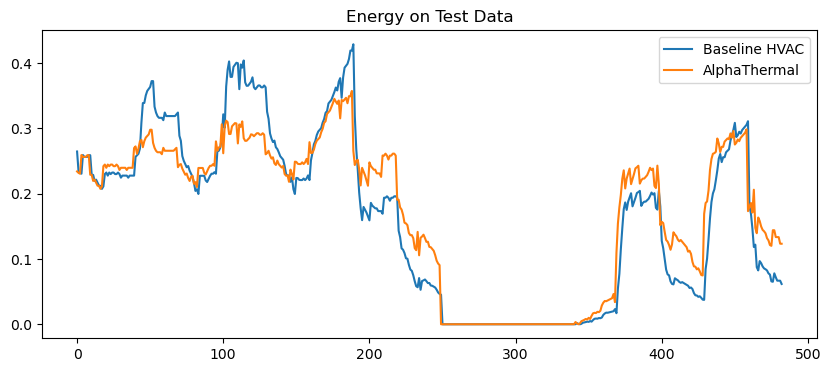

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(baseline_energy, label="Baseline HVAC")
plt.plot(model_energy, label="AlphaThermal")
plt.legend()
plt.title("Energy on Test Data")
plt.show()